
# Persistent Matmul
This script demonstrates persistent kernel implementations of matrix multiplication using Triton.
Various matmul methods are included, such as naive, persistent, and TMA (Tensor Memory Accelerator) based approaches.
The kernels support both FP16 and FP8 data types but the FP8 implementation is only available on CUDA devices with compute capability >= 9.0.

Triton and cuBLAS implementations are benchmarked under different configurations and evaluated using the proton profiler.
Users can pass command-line arguments to specify matrix dimensions and iteration steps flexibly.

```bash
# FP8
python 09-persistent-matmul.py --prec fp8 --K_range 128 1024 --K_step 128

# FP16
python 09-persistent-matmul.py --prec fp16 --K_range 128 1024 --K_step 128
```
Note that currently this tutorial will fail on devices with a small shared memory size, such as RTX-4090.


In [2]:
import torch
from torch import Tensor, nn
from math import ceil
from torch.autograd import Function
import os
from torch.autograd.function import Function
import triton
from typing import Optional
from copy import deepcopy
import triton.language as tl

DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(DEVICE)

cuda


In [37]:

def get_cuda_autotune_config():
    return [
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 64, 'GROUP_SIZE_M': 8}, num_stages=3,
                      num_warps=8),
        triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 32, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 32, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=5,
                      num_warps=2),
        triton.Config({'BLOCK_SIZE_M': 32, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=5,
                      num_warps=2),
        # Good config for fp8 inputs.
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 8}, num_stages=3,
                      num_warps=8),
        triton.Config({'BLOCK_SIZE_M': 256, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 8}, num_stages=3,
                      num_warps=8),
        triton.Config({'BLOCK_SIZE_M': 256, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 8}, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 8}, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 8}, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 64, 'GROUP_SIZE_M': 8}, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 64, 'GROUP_SIZE_M': 8}, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 32, 'BLOCK_SIZE_K': 64, 'GROUP_SIZE_M': 8}, num_stages=4,
                      num_warps=4)
    ]

In [38]:

# `triton.jit`'ed functions can be auto-tuned by using the `triton.autotune` decorator, which consumes:
#   - A list of `triton.Config` objects that define different configurations of
#       meta-parameters (e.g., `BLOCK_SIZE_M`) and compilation options (e.g., `num_warps`) to try
#   - An auto-tuning *key* whose change in values will trigger evaluation of all the
#       provided configs
@triton.autotune(
    configs=get_cuda_autotune_config(),
    key=['M', 'N', 'K'],
)
@triton.jit
def matmul_kernel(
        # Pointers to matrices
        a_ptr, b_ptr, c_ptr,
        # Matrix dimensions
        M, N, K,
        # The stride variables represent how much to increase the ptr by when moving by 1
        # element in a particular dimension. E.g. `stride_am` is how much to increase `a_ptr`
        # by to get the element one row down (A has M rows).
        stride_am, stride_ak,  #
        stride_bk, stride_bn,  #
        stride_cm, stride_cn,
        # Meta-parameters
        BLOCK_SIZE_M: tl.constexpr, BLOCK_SIZE_N: tl.constexpr, BLOCK_SIZE_K: tl.constexpr,  #
        GROUP_SIZE_M: tl.constexpr,  #
        ACTIVATION: tl.constexpr  #
):
    """Kernel for computing the matmul C = A x B.
    A has shape (M, K), B has shape (K, N) and C has shape (M, N)
    """
    # -----------------------------------------------------------
    # Map program ids `pid` to the block of C it should compute.
    # This is done in a grouped ordering to promote L2 data reuse.
    # See above `L2 Cache Optimizations` section for details.
    pid = tl.program_id(axis=0)
    num_pid_m = tl.cdiv(M, BLOCK_SIZE_M)
    num_pid_n = tl.cdiv(N, BLOCK_SIZE_N)
    num_pid_in_group = GROUP_SIZE_M * num_pid_n
    group_id = pid // num_pid_in_group
    first_pid_m = group_id * GROUP_SIZE_M
    group_size_m = min(num_pid_m - first_pid_m, GROUP_SIZE_M)
    pid_m = first_pid_m + ((pid % num_pid_in_group) % group_size_m)
    pid_n = (pid % num_pid_in_group) // group_size_m

    # -----------------------------------------------------------
    # Add some integer bound assumptions.
    # This helps to guide integer analysis in the backend to optimize
    # load/store offset address calculation
    tl.assume(pid_m >= 0)
    tl.assume(pid_n >= 0)
    tl.assume(stride_am > 0)
    tl.assume(stride_ak > 0)
    tl.assume(stride_bn > 0)
    tl.assume(stride_bk > 0)
    tl.assume(stride_cm > 0)
    tl.assume(stride_cn > 0)

    # ----------------------------------------------------------
    # Create pointers for the first blocks of A and B.
    # We will advance this pointer as we move in the K direction
    # and accumulate
    # `a_ptrs` is a block of [BLOCK_SIZE_M, BLOCK_SIZE_K] pointers
    # `b_ptrs` is a block of [BLOCK_SIZE_K, BLOCK_SIZE_N] pointers
    # See above `Pointer Arithmetic` section for details
    offs_am = (pid_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)) % M
    offs_bn = (pid_n * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)) % N
    offs_k = tl.arange(0, BLOCK_SIZE_K)
    a_ptrs = a_ptr + (offs_am[:, None] * stride_am + offs_k[None, :] * stride_ak)
    b_ptrs = b_ptr + (offs_k[:, None] * stride_bk + offs_bn[None, :] * stride_bn)

    # -----------------------------------------------------------
    # Iterate to compute a block of the C matrix.
    # We accumulate into a `[BLOCK_SIZE_M, BLOCK_SIZE_N]` block
    # of fp32 values for higher accuracy.
    # `accumulator` will be converted back to fp16 after the loop.
    accumulator = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)
    for k in range(0, tl.cdiv(K, BLOCK_SIZE_K)):
        # Load the next block of A and B, generate a mask by checking the K dimension.
        # If it is out of bounds, set it to 0.
        a = tl.load(a_ptrs, mask=offs_k[None, :] < K - k * BLOCK_SIZE_K, other=0.0)
        b = tl.load(b_ptrs, mask=offs_k[:, None] < K - k * BLOCK_SIZE_K, other=0.0)
        # We accumulate along the K dimension.
        accumulator = tl.dot(a, b, accumulator)
        # Advance the ptrs to the next K block.
        a_ptrs += BLOCK_SIZE_K * stride_ak
        b_ptrs += BLOCK_SIZE_K * stride_bk
    # You can fuse arbitrary activation functions here
    # while the accumulator is still in FP32!
    c = accumulator.to(tl.float16)

    # -----------------------------------------------------------
    # Write back the block of the output matrix C with masks.
    offs_cm = pid_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)
    offs_cn = pid_n * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)
    c_ptrs = c_ptr + stride_cm * offs_cm[:, None] + stride_cn * offs_cn[None, :]
    c_mask = (offs_cm[:, None] < M) & (offs_cn[None, :] < N)
    tl.store(c_ptrs, c, mask=c_mask)



def matmul(a, b, activation=""):
    # Check constraints.
    assert a.shape[1] == b.shape[0], "Incompatible dimensions"
    assert a.is_contiguous(), "Matrix A must be contiguous"
    M, K = a.shape
    K, N = b.shape
    # Allocates output.
    c = torch.empty((M, N), device=a.device, dtype=torch.float16)
    # 1D launch kernel where each block gets its own program.
    grid = lambda META: (triton.cdiv(M, META['BLOCK_SIZE_M']) * triton.cdiv(N, META['BLOCK_SIZE_N']), )
    matmul_kernel[grid](
        a, b, c,  #
        M, N, K,  #
        a.stride(0), a.stride(1),  #
        b.stride(0), b.stride(1),  #
        c.stride(0), c.stride(1),  #
        ACTIVATION=activation  #
    )
    return c

In [41]:

# @triton.autotune(
#     configs=get_cuda_autotune_config(),
#     key=['M', 'N', 'K'],
# )
@triton.jit()
def _eager_matmul_triton(
        a_ptr,
        b_ptr,
        c_ptr,
        M,
        N,
        K,
        stride_am,
        stride_ak,
        stride_bk,
        stride_bn,
        stride_cn,
        stride_cm,
        BLOCK_SIZE_M: tl.constexpr,
        BLOCK_SIZE_N: tl.constexpr,
        BLOCK_SIZE_K: tl.constexpr,  #
        GROUP_SIZE_M: tl.constexpr,  #
    ):

    pid = tl.program_id(axis=0)

    #
    n_programs_n = tl.cdiv(N, BLOCK_SIZE_N)

    # map global pid to (pid_m, pid_n)
    pid_m = pid // n_programs_n
    pid_n = pid % n_programs_n

    # offsets along dimensions m, n, k
    offset_ptr_m = pid_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)
    offset_ptr_n = pid_n * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)
    offset_ptr_k = tl.arange(0, BLOCK_SIZE_K)

    # get pointers for first tiles tile_a, tile_b
    tile_a_ptr = a_ptr + offset_ptr_m[:, None] * stride_am + offset_ptr_k[None, :] * stride_ak
    tile_b_ptr = b_ptr + offset_ptr_k[:, None] * stride_bk + offset_ptr_n[None, :] * stride_bn

    tile_c = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)

    # loop over dimension k
    for k in tl.range(0, tl.cdiv(K, BLOCK_SIZE_K)):

        # if K % k != 0 -> mask out the items after K
        items_after_K = K - k * BLOCK_SIZE_K

        # materialize the masks along the Z dimenison for tile_a, tile_b
        # mask_ak = offset_ptr_k[None, :] < items_after_K # mask along 1st dim
        # mask_bk = offset_ptr_k[:, None] < items_after_K # mask along 2nd dim

        # Create masks that check BOTH dimensions
        # For A: Check M (rows) AND K (cols)
        mask_ak = (offset_ptr_m[:, None] < M) & (offset_ptr_k[None, :] < items_after_K)

        # # For B: Check K (rows) AND N (cols)
        mask_bk = (offset_ptr_k[:, None] < items_after_K) & (offset_ptr_n[None, :] < N)

        tile_a = tl.load(tile_a_ptr, mask_ak, other=0.0)
        tile_b = tl.load(tile_b_ptr, mask_bk, other=0.0)

        tile_c = tl.dot(tile_a, tile_b, acc=tile_c)

        # now slide the tile_a, tile_b pointers along Z direction of k steps
        tile_a_ptr += BLOCK_SIZE_K * stride_ak
        tile_b_ptr += BLOCK_SIZE_K * stride_bk

    # tile_c = tile_c.to(tl.bfloat16)

    # get c global pointers and store the output
    tile_c_ptr = c_ptr + offset_ptr_m[:, None] * stride_cm + offset_ptr_n[None, :] * stride_cn
    mask_c = (offset_ptr_m[:, None] < M) & (offset_ptr_n[None, :] < N)
    tl.store(tile_c_ptr, tile_c, mask=mask_c)




def eager_matmul(a: Tensor, b: Tensor):
    assert a.ndim == 2, "expected A to have ndim=2"
    assert b.ndim == 2, "expected B to have ndim=2"
    assert a.shape[1] == b.shape[0], "dimension mismatch"

    M, K = a.shape
    N = b.shape[1]

    c = torch.zeros(M, N).to(DEVICE)

    # these will be tuned via autotune and provided as metaparameters
    block_size_M, block_size_N, block_size_K = (64, 64, 64)
    # block_size_M, block_size_N, block_size_K = (2, 2, 2)
    group_size_M = 8

    # grid = lambda META: (triton.cdiv(M, META['BLOCK_SIZE_M']) * triton.cdiv(N, META['BLOCK_SIZE_N']), )
    grid = (ceil(M / block_size_M) * ceil(N / block_size_N), )

    _eager_matmul_triton[grid](
        a,
        b,
        c,
        M,
        N,
        K,
        a.stride(0),
        a.stride(1),
        b.stride(0),
        b.stride(1),
        c.stride(0),
        c.stride(1),
        block_size_M,
        block_size_N,
        block_size_K,
        group_size_M,
    )

    return c


testing for conf: M=32, N=32, K=32, provider='triton'
testing for conf: M=32, N=32, K=32, provider='eager_triton'
testing for conf: M=32, N=32, K=32, provider='torch'
testing for conf: M=160, N=160, K=160, provider='triton'
testing for conf: M=160, N=160, K=160, provider='eager_triton'
testing for conf: M=160, N=160, K=160, provider='torch'
testing for conf: M=288, N=288, K=288, provider='triton'
testing for conf: M=288, N=288, K=288, provider='eager_triton'
testing for conf: M=288, N=288, K=288, provider='torch'
testing for conf: M=416, N=416, K=416, provider='triton'
testing for conf: M=416, N=416, K=416, provider='eager_triton'
testing for conf: M=416, N=416, K=416, provider='torch'
testing for conf: M=544, N=544, K=544, provider='triton'
testing for conf: M=544, N=544, K=544, provider='eager_triton'
testing for conf: M=544, N=544, K=544, provider='torch'
testing for conf: M=672, N=672, K=672, provider='triton'
testing for conf: M=672, N=672, K=672, provider='eager_triton'
testing f

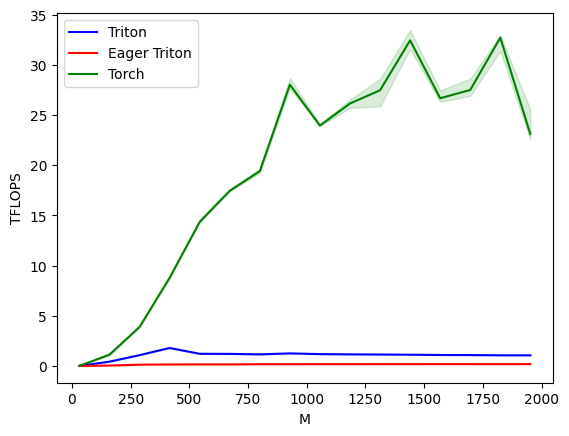

matmul-performance:
         M       N       K    Triton  Eager Triton      Torch
0     32.0    32.0    32.0  0.004201      0.000355   0.008000
1    160.0   160.0   160.0  0.427379      0.037389   1.120350
2    288.0   288.0   288.0  1.076418      0.127020   3.888000
3    416.0   416.0   416.0  1.792255      0.148463   8.788000
4    544.0   544.0   544.0  1.209354      0.154532  14.353530
5    672.0   672.0   672.0  1.200831      0.155335  17.456537
6    800.0   800.0   800.0  1.152987      0.173562  19.417476
7    928.0   928.0   928.0  1.249967      0.172521  28.045295
8   1056.0  1056.0  1056.0  1.178262      0.177961  23.957999
9   1184.0  1184.0  1184.0  1.155397      0.175077  26.166564
10  1312.0  1312.0  1312.0  1.136722      0.181237  27.485192
11  1440.0  1440.0  1440.0  1.118246      0.183386  32.461995
12  1568.0  1568.0  1568.0  1.092028      0.184343  26.691610
13  1696.0  1696.0  1696.0  1.084965      0.183827  27.515576
14  1824.0  1824.0  1824.0  1.062449      0.183255

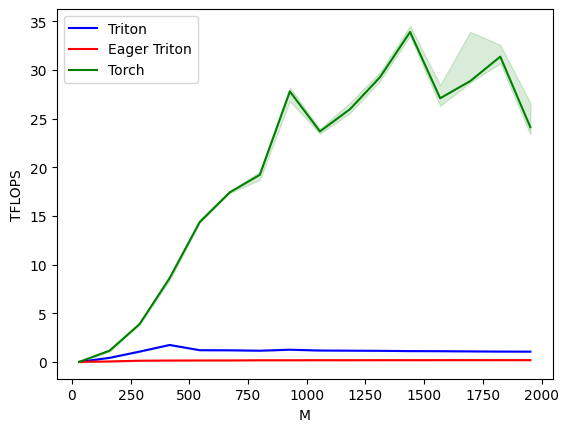

matmul-performance:
         M       N       K    Triton  Eager Triton      Torch
0     32.0    32.0    32.0  0.007474      0.000681   0.012047
1    160.0   160.0   160.0  0.420361      0.050753   1.155756
2    288.0   288.0   288.0  1.060364      0.124775   3.888000
3    416.0   416.0   416.0  1.744651      0.142604   8.619647
4    544.0   544.0   544.0  1.206960      0.152131  14.374035
5    672.0   672.0   672.0  1.196853      0.153498  17.432470
6    800.0   800.0   800.0  1.154401      0.172798  19.230769
7    928.0   928.0   928.0  1.255686      0.172359  27.803324
8   1056.0  1056.0  1056.0  1.173855      0.178016  23.695743
9   1184.0  1184.0  1184.0  1.158610      0.175345  25.983054
10  1312.0  1312.0  1312.0  1.141770      0.180958  29.278200
11  1440.0  1440.0  1440.0  1.114339      0.182103  33.919302
12  1568.0  1568.0  1568.0  1.106311      0.184038  27.105991
13  1696.0  1696.0  1696.0  1.085455      0.183917  28.873114
14  1824.0  1824.0  1824.0  1.064713      0.184378

In [42]:
ref_lib = 'cuBLAS'

configs = []
for fp8_inputs in [False, True]:
    # if fp8_inputs and (not TORCH_HAS_FP8 or not is_cuda()):
        # continue
    configs.append(
        triton.testing.Benchmark(
            x_names=["M", "N", "K"],  # Argument names to use as an x-axis for the plot
            x_vals=[16 * i for i in range(2, 128, 8)],  # Different possible values for `x_name`
            line_arg="provider",  # Argument name whose value corresponds to a different line in the plot
            # Possible values for `line_arg`
            # Don't compare to cublas for fp8 cases as torch.matmul doesn't support fp8 at the moment.
            line_vals=['triton', 'eager_triton', 'torch'],  # possible values for `line_arg``
            line_names=["Triton", "Eager Triton",  "Torch"],  # label name for the lines
            styles=[('blue', '-'), ('red', '-'), ('green', '-')],  # line styles
            ylabel="TFLOPS",  # Label name for the y-axis
            plot_name="matmul-performance",
            args = {},
        ))


@triton.testing.perf_report(configs)
def benchmark(M, N, K, provider):
    print(f"testing for conf: {M=}, {N=}, {K=}, {provider=}")
    a = torch.randn((M, K), device=DEVICE, dtype=torch.float16)
    b = torch.randn((K, N), device=DEVICE, dtype=torch.float16)
    # if TORCH_HAS_FP8 and fp8_inputs:
    #     a = a.to(torch.float8_e5m2)
    #     b = b.T
    #     b = b.to(torch.float8_e5m2)
    quantiles = [0.5, 0.2, 0.8]
    if provider == 'torch':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: torch.matmul(a, b), quantiles=quantiles)
    if provider == 'triton':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: matmul(a, b), quantiles=quantiles)
    if provider == 'eager_triton':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: eager_matmul(a, b), quantiles=quantiles)
    perf = lambda ms: 2 * M * N * K * 1e-12 / (ms * 1e-3)
    return perf(ms), perf(max_ms), perf(min_ms)


benchmark.run(show_plots=True, print_data=True)

In [ ]:

@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['N'],  # argument names to use as an x-axis for the plot
        x_vals=[128 * i for i in range(2, 50, 10)],  # different possible values for `x_name`
        line_arg='provider',  # argument name whose value corresponds to a different line in the plot
        line_vals=['triton', 'torch'],  # possible values for `line_arg``
        line_names=["Triton", "Torch"],  # label name for the lines
        styles=[('blue', '-'), ('green', '-')],  # line styles
        ylabel="GB/s",  # label name for the y-axis
        plot_name="softmax-performance",  # name for the plot. Used also as a file name for saving the plot.
        args={'M': 4096},  # values for function arguments not in `x_names` and `y_name`
    ))


def benchmark(M, N, provider):
    x = torch.randn(M, N, device=DEVICE, dtype=torch.bfloat16)
    stream = getattr(torch, DEVICE.type).Stream()
    getattr(torch, DEVICE.type).set_stream(stream)
    ms = triton.testing.do_bench(lambda: fwd(x, provider))
    # if provider == 'torch':
        # ms = triton.testing.do_bench(lambda: fwd(x, provider))
    # if provider == 'triton':
    gbps = lambda ms: 2 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
    return gbps(ms)
